In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

In [6]:
df=pd.read_csv('/content/brca.csv')

In [7]:
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [8]:
df.tail()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
564,565,20.92,25.09,143.0,1347.0,0.10990,0.2236,0.31740,0.14740,0.2149,...,29.41,179.1,1819.0,0.1407,0.4186,0.6599,0.2542,0.2929,0.09873,M
565,566,21.56,22.39,142.0,1479.0,0.11100,0.1159,0.24390,0.13890,0.1726,...,26.40,166.1,2027.0,0.1410,0.2113,0.4107,0.2216,0.2060,0.07115,M
566,567,20.13,28.25,131.2,1261.0,0.09780,0.1034,0.14400,0.09791,0.1752,...,38.25,155.0,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.06637,M
567,568,16.60,28.08,108.3,858.1,0.08455,0.1023,0.09251,0.05302,0.1590,...,34.12,126.7,1124.0,0.1139,0.3094,0.3403,0.1418,0.2218,0.07820,M
568,569,20.60,29.33,140.1,1265.0,0.11780,0.2770,0.35140,0.15200,0.2397,...,39.42,184.6,1821.0,0.1650,0.8681,0.9387,0.2650,0.4087,0.12400,M


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [10]:
df.shape

(569, 32)

In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
x.radius_mean,0
x.texture_mean,0
x.perimeter_mean,0
x.area_mean,0
x.smoothness_mean,0
x.compactness_mean,0
x.concavity_mean,0
x.concave_pts_mean,0
x.symmetry_mean,0


In [12]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

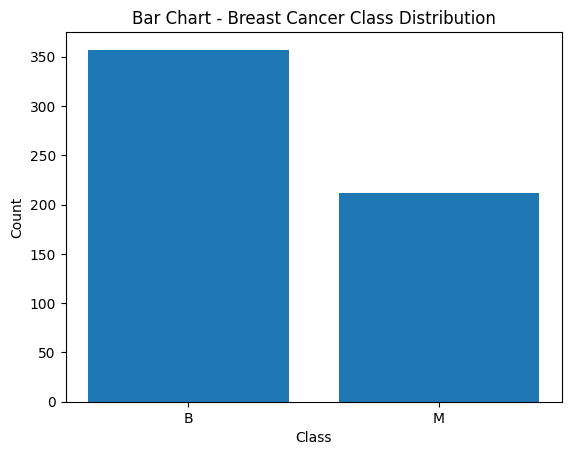

In [13]:
counts = df['y'].value_counts()
plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Bar Chart - Breast Cancer Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

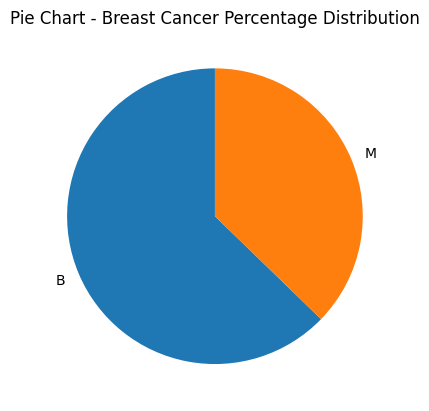

In [14]:
plt.figure()
plt.pie(counts.values, labels=counts.index, startangle=90)
plt.title("Pie Chart - Breast Cancer Percentage Distribution")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [16]:
X = df.drop('y', axis=1)
y = df['y']


In [17]:
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)


In [18]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [21]:
model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)

In [22]:
model.fit(X_train, y_train)


GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [23]:
y_pred = model.predict(X_test)


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544
